Loading the Dataset and Creating Columns

In [ ]:
import pandas as pd

#naming the columns
columns = ['unit_number', 'time_cycles', 'op_setting_1', 'op_setting_2', 'op_setting_3'] + \
          [f'sensor_{i}' for i in range(1, 22)]

#load the dataset (its separated by space)
df = pd.read_csv('/content/train_FD001.txt', sep='\s+', header=None, names=columns)

grouped = df.groupby('unit_number') #groups the data by each unit number
max_cycles = grouped['time_cycles'].max() #finds the maximum amount of time cycles for every unit
df = df.merge(max_cycles.rename('max_cycle'), on='unit_number') #adds the above max cycles column to it's corresponding unit
df['RUL'] = df['max_cycle'] - df['time_cycles'] #caluclates the "Remaining Useful Life" for each instance by subtracting maximum - current
df['Status'] = (df['RUL'] <= 30).astype(int) # = 0 when RUL is normal (> 30) , = 1 when at risk (<=30)

df = df.drop(['max_cycle', 'RUL'], axis=1)

print("Dataset Shape:", df.shape)
print("\nColumns:", df.columns.tolist())
print("\nClass Distribution:")
print(df['Status'].value_counts(normalize=True))

Dataset Shape: (20631, 27)

Columns: ['unit_number', 'time_cycles', 'op_setting_1', 'op_setting_2', 'op_setting_3', 'sensor_1', 'sensor_2', 'sensor_3', 'sensor_4', 'sensor_5', 'sensor_6', 'sensor_7', 'sensor_8', 'sensor_9', 'sensor_10', 'sensor_11', 'sensor_12', 'sensor_13', 'sensor_14', 'sensor_15', 'sensor_16', 'sensor_17', 'sensor_18', 'sensor_19', 'sensor_20', 'sensor_21', 'Status']

Class Distribution:
Status
0    0.849741
1    0.150259
Name: proportion, dtype: float64


Exploratory Data Analysis

Missing Values:
 unit_number     0
time_cycles     0
op_setting_1    0
op_setting_2    0
op_setting_3    0
sensor_1        0
sensor_2        0
sensor_3        0
sensor_4        0
sensor_5        0
sensor_6        0
sensor_7        0
sensor_8        0
sensor_9        0
sensor_10       0
sensor_11       0
sensor_12       0
sensor_13       0
sensor_14       0
sensor_15       0
sensor_16       0
sensor_17       0
sensor_18       0
sensor_19       0
sensor_20       0
sensor_21       0
Status          0
dtype: int64

Top 10 Correlations with Status:
 Status         1.000000
sensor_11      0.665655
sensor_4       0.648406
sensor_15      0.618732
sensor_17      0.583067
sensor_2       0.581404
sensor_3       0.561892
sensor_8       0.542910
sensor_13      0.539915
time_cycles    0.503679
Name: Status, dtype: float64

Bottom 10 Correlations with Status:
 sensor_21      -0.606480
sensor_7       -0.625592
sensor_12      -0.640174
op_setting_3         NaN
sensor_1             NaN
sensor_5         

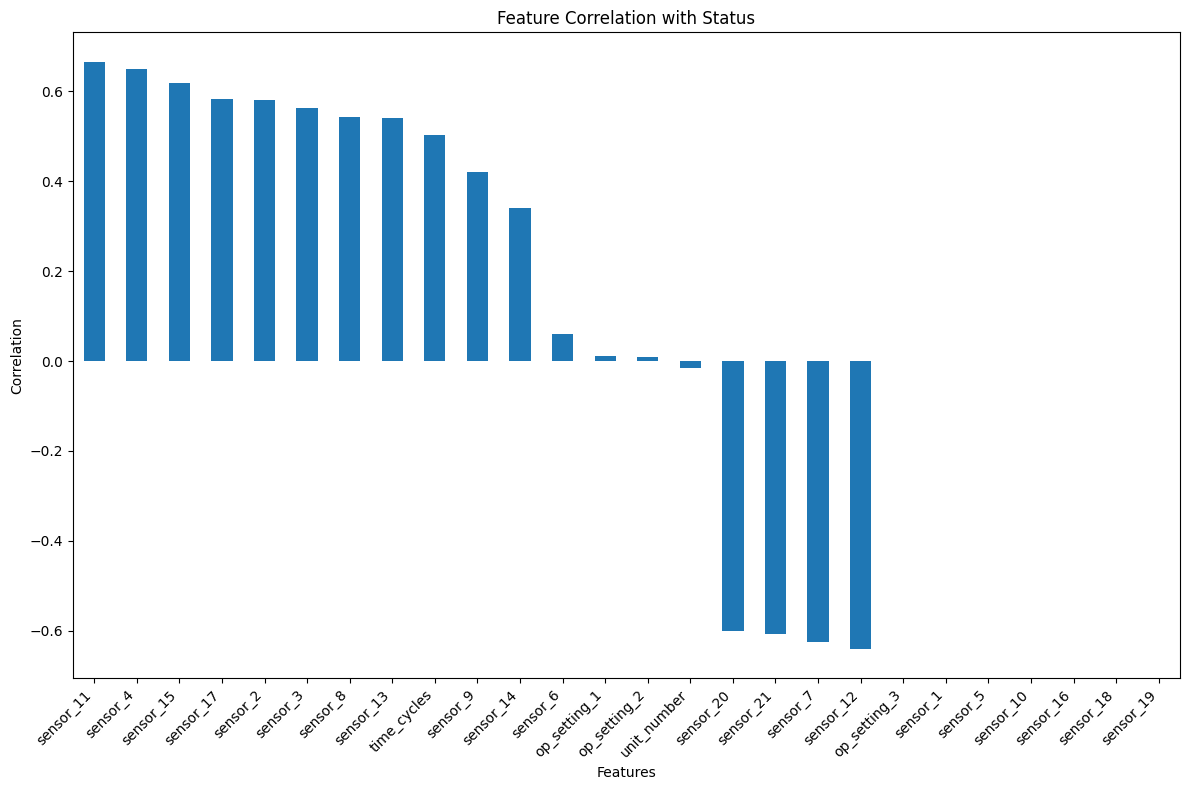


Bottom 5 Feature Variances:
 op_setting_3    0.000000e+00
sensor_18       0.000000e+00
sensor_19       0.000000e+00
sensor_16       2.422479e-28
sensor_10       2.172333e-25
dtype: float64


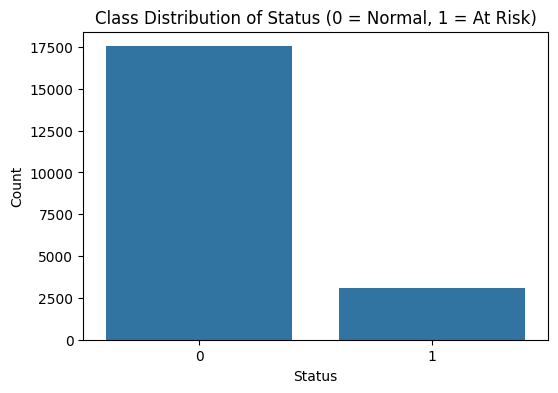

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

#checking for missing data points
print("Missing Values:\n", df.isnull().sum())

#checking feature correlation with status
correlations = df.corr()['Status'].sort_values(ascending=False)
print("\nTop 10 Correlations with Status:\n", correlations.head(10))
print("\nBottom 10 Correlations with Status:\n", correlations.tail(10))

plt.figure(figsize=(12, 8))
correlations.drop('Status').plot(kind='bar')
plt.title('Feature Correlation with Status')
plt.xlabel('Features')
plt.ylabel('Correlation')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

#checking the variance of the features
variances = df.var()
print("\nBottom 5 Feature Variances:\n", variances.sort_values().head(5))

#visualizing the distribution of engine status looking for imbalance
plt.figure(figsize=(6, 4))
sns.countplot(x='Status', data=df)
plt.title('Class Distribution of Status (0 = Normal, 1 = At Risk)')
plt.xlabel('Status')
plt.ylabel('Count')
plt.show()

Updated Dataset Shape: (20631, 20)

Columns: ['unit_number', 'time_cycles', 'op_setting_1', 'op_setting_2', 'sensor_2', 'sensor_3', 'sensor_4', 'sensor_6', 'sensor_7', 'sensor_8', 'sensor_9', 'sensor_11', 'sensor_12', 'sensor_13', 'sensor_14', 'sensor_15', 'sensor_17', 'sensor_20', 'sensor_21', 'Status']


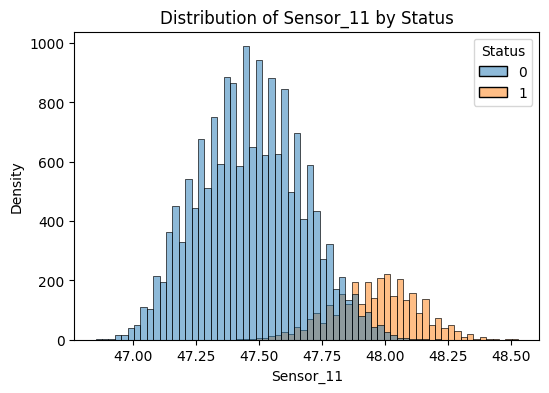

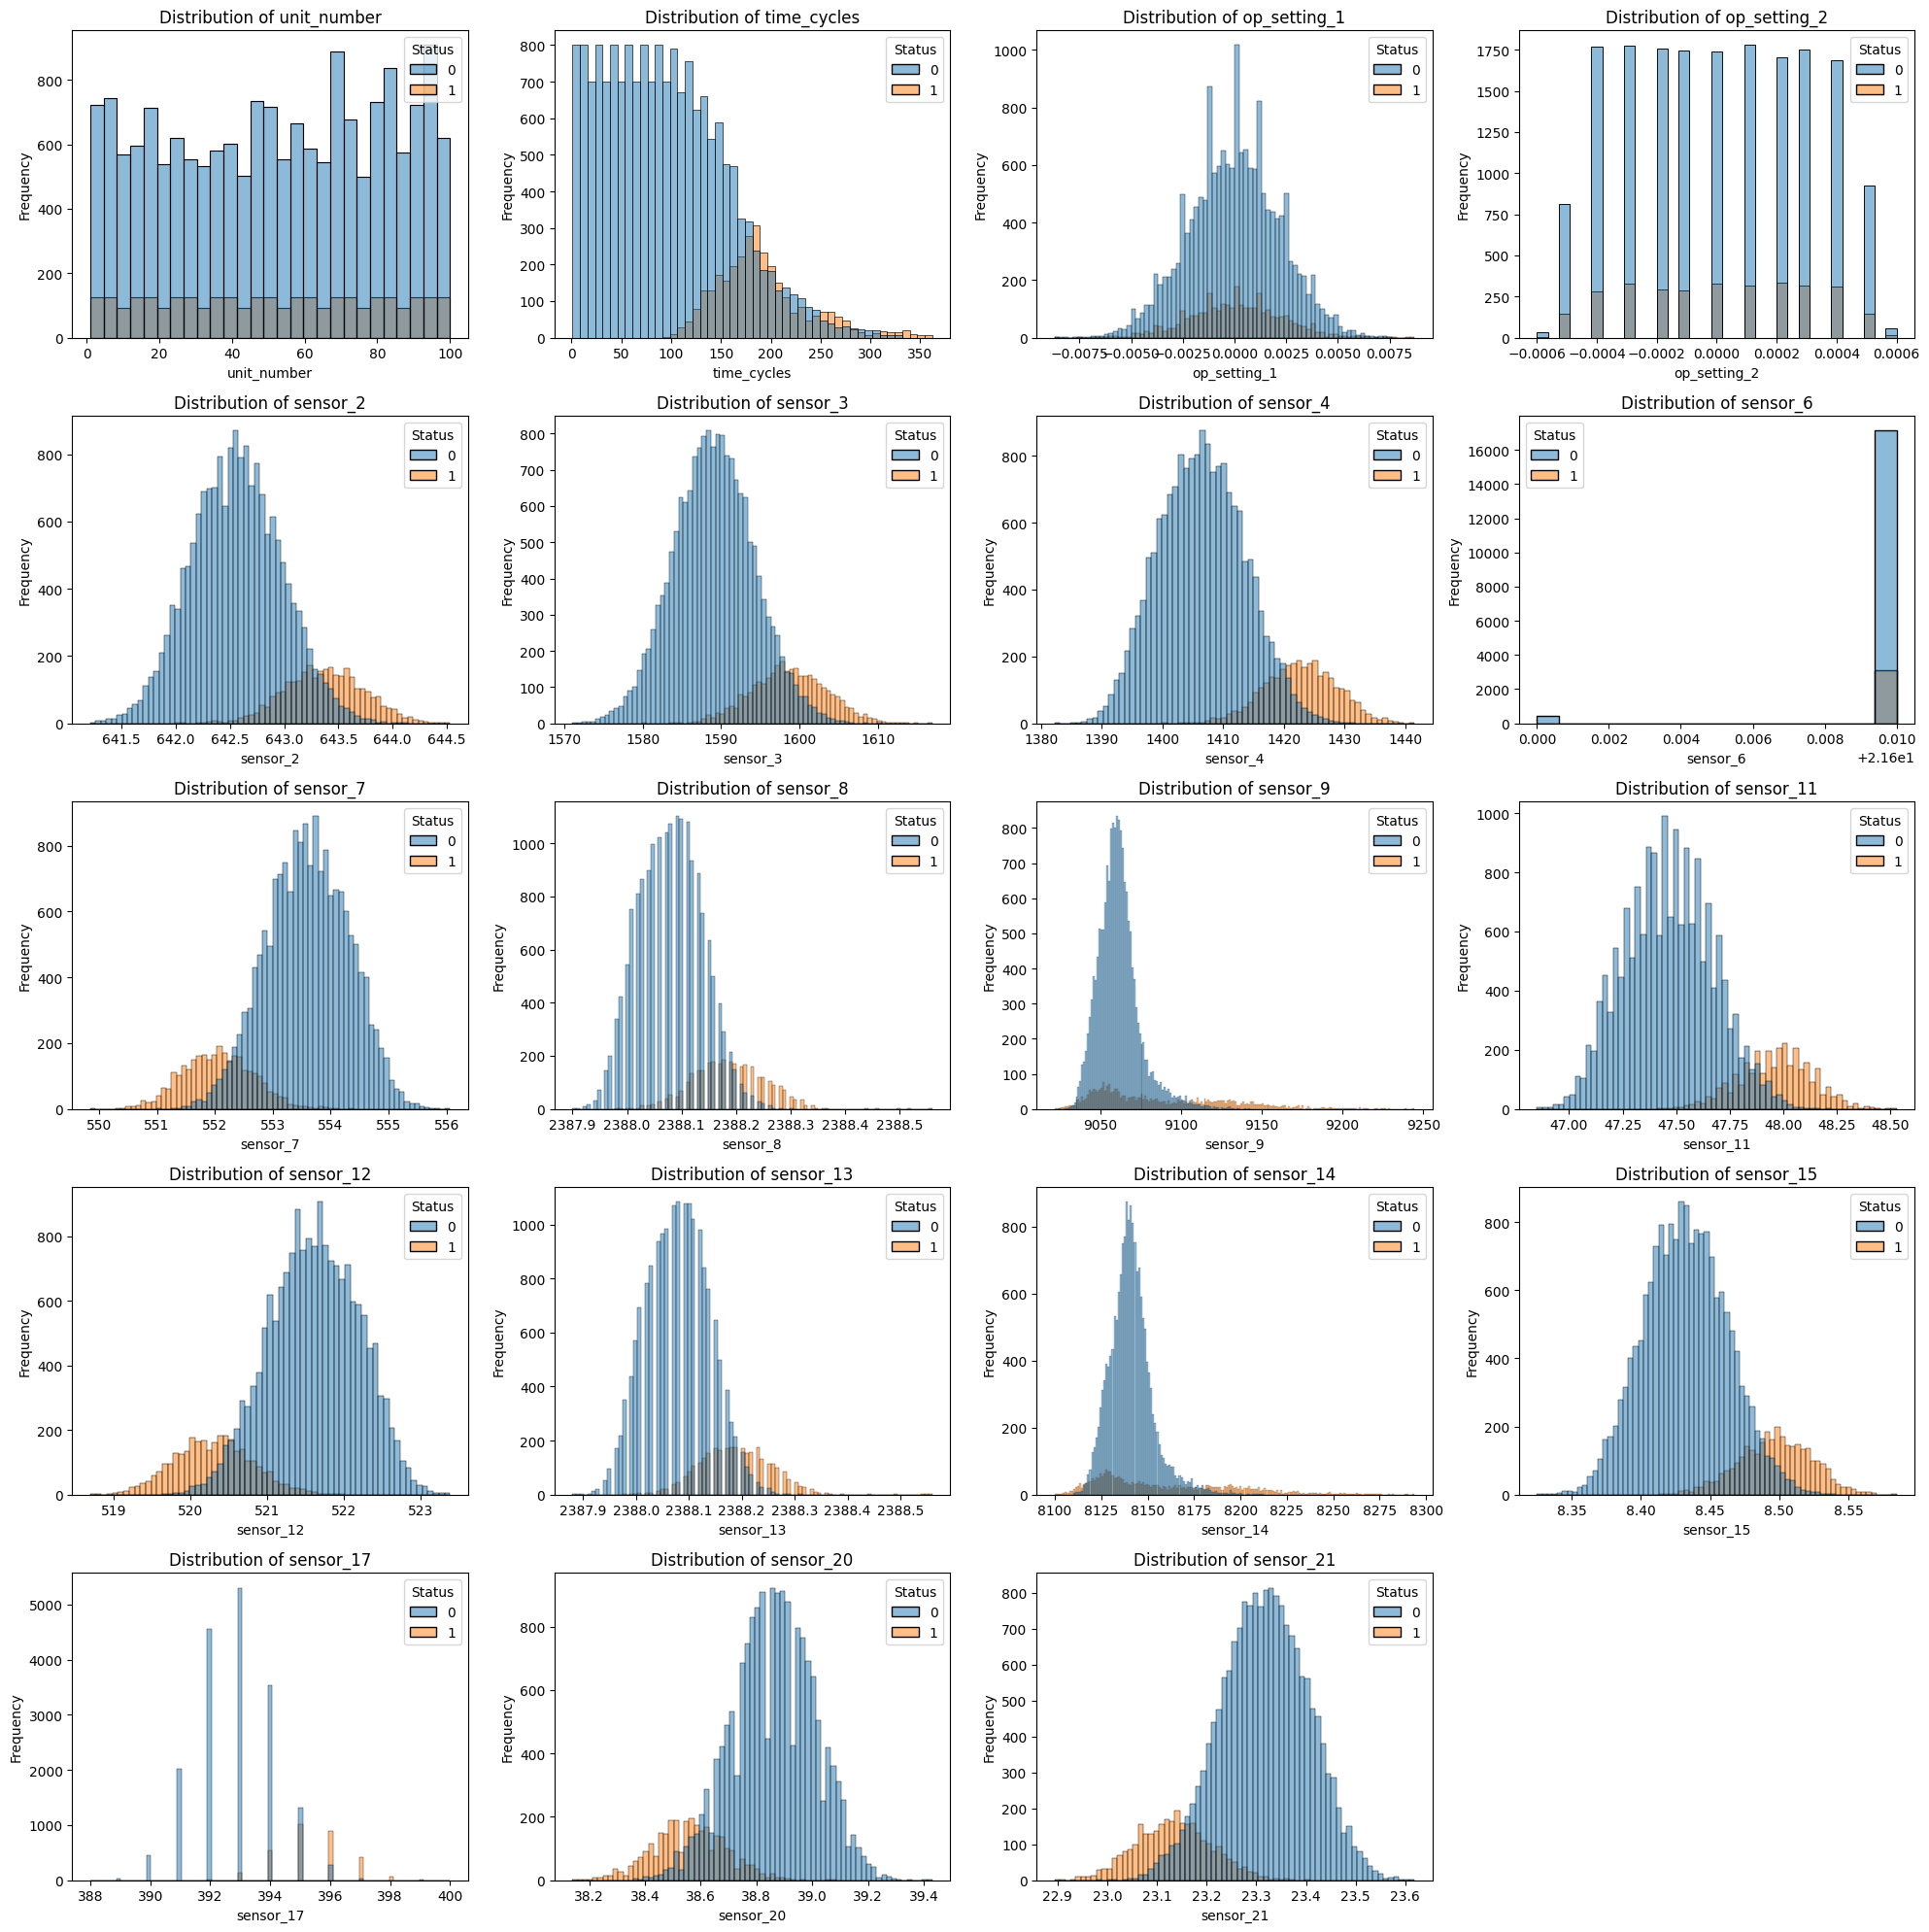

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

#removing the features with no correlation and 0 variance
irrelevant_features = ['op_setting_3', 'sensor_1', 'sensor_5', 'sensor_10', 'sensor_16', 'sensor_18', 'sensor_19']
df = df.drop(columns=irrelevant_features)

print("Updated Dataset Shape:", df.shape)
print("\nColumns:", df.columns.tolist())

#plot sensor 11 because it has the highest correlation and to see if it will separate the status or skewed
plt.figure(figsize=(6, 4))
sns.histplot(data=df, x='sensor_11', hue='Status')
plt.title('Distribution of Sensor_11 by Status')
plt.xlabel('Sensor_11')
plt.ylabel('Density')
plt.show()

features = df.drop(columns=['Status']).columns

#grid of histograms 5x4
fig, axes = plt.subplots(5, 4, figsize=(20, 20))
axes = axes.flatten()

#histograms for every feature
for i, feature in enumerate(features):
    sns.histplot(data=df, x=feature, ax=axes[i], hue='Status')
    axes[i].set_title(f'Distribution of {feature}')
    axes[i].set_xlabel(feature)
    axes[i].set_ylabel('Frequency')

#remove empty subplots
for i in range(len(features), len(axes)):
    fig.delaxes(axes[i])

plt.tight_layout()
plt.show()

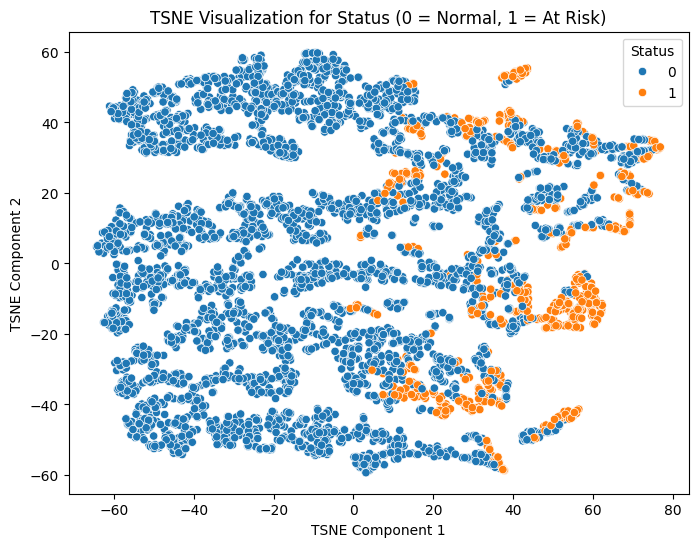

In [ ]:
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
import seaborn as sns

#TSNE visualization but colab crashes when I used the full dataset so I had to subset
df_subset = df.sample(5000, random_state=1)
X_subset = df_subset.drop('Status', axis=1)
y_subset = df_subset['Status']

tsne = TSNE(n_components=2, random_state=1)
X_tsne = tsne.fit_transform(X_subset)

#TSNE Plot
plt.figure(figsize=(8, 6))
sns.scatterplot(x=X_tsne[:, 0], y=X_tsne[:, 1], hue=y_subset)
plt.title('TSNE Visualization for Status (0 = Normal, 1 = At Risk)')
plt.xlabel('TSNE Component 1')
plt.ylabel('TSNE Component 2')
plt.show()

Feature Engineering

In [ ]:
import pandas as pd
from sklearn.preprocessing import StandardScaler

#creating new features
top_sensors = ['sensor_11', 'sensor_4', 'sensor_15', 'sensor_17', 'sensor_2', 'sensor_3']
for sensor in top_sensors:
    #calculates the average of every 5 cycles
    df[f'{sensor}_avg_of5'] = df.groupby('unit_number')[sensor].rolling(window=5, min_periods=1).mean().reset_index(drop=True)
    #calculates the rate of change
    df[f'{sensor}_diff'] = df.groupby('unit_number')[sensor].diff().fillna(0)

#normalize the time cycles
df['normalized_cycles'] = df.groupby('unit_number')['time_cycles'].transform(lambda x: x / x.max())

#scales/normalizes everything else except for status and unit number
features = [col for col in df.columns if col != 'Status' and col != 'unit_number']
scaler = StandardScaler()
df[features] = scaler.fit_transform(df[features])

print("Updated Dataset Shape:", df.shape)
print("\nNew Columns:", df.columns.tolist())

Updated Dataset Shape: (20631, 33)

New Columns: ['unit_number', 'time_cycles', 'op_setting_1', 'op_setting_2', 'sensor_2', 'sensor_3', 'sensor_4', 'sensor_6', 'sensor_7', 'sensor_8', 'sensor_9', 'sensor_11', 'sensor_12', 'sensor_13', 'sensor_14', 'sensor_15', 'sensor_17', 'sensor_20', 'sensor_21', 'Status', 'sensor_11_avg_of5', 'sensor_11_diff', 'sensor_4_avg_of5', 'sensor_4_diff', 'sensor_15_avg_of5', 'sensor_15_diff', 'sensor_17_avg_of5', 'sensor_17_diff', 'sensor_2_avg_of5', 'sensor_2_diff', 'sensor_3_avg_of5', 'sensor_3_diff', 'normalized_cycles']


Feature Selection

Top 15 Features by Mutual Information:
               Feature  Mutual_Information
31  normalized_cycles            0.371528
19  sensor_11_avg_of5            0.303893
21   sensor_4_avg_of5            0.299128
23  sensor_15_avg_of5            0.294888
27   sensor_2_avg_of5            0.284267
25  sensor_17_avg_of5            0.282936
29   sensor_3_avg_of5            0.274538
11          sensor_11            0.265888
6            sensor_4            0.250846
12          sensor_12            0.244935
8            sensor_7            0.233073
15          sensor_15            0.224943
18          sensor_21            0.217842
17          sensor_20            0.209696
4            sensor_2            0.196315

Selected Features: ['normalized_cycles', 'sensor_11_avg_of5', 'sensor_4_avg_of5', 'sensor_15_avg_of5', 'sensor_2_avg_of5', 'sensor_17_avg_of5', 'sensor_3_avg_of5', 'sensor_11', 'sensor_4', 'sensor_12', 'sensor_7', 'sensor_15', 'sensor_21', 'sensor_20', 'sensor_2']
Shape of Selected Feat

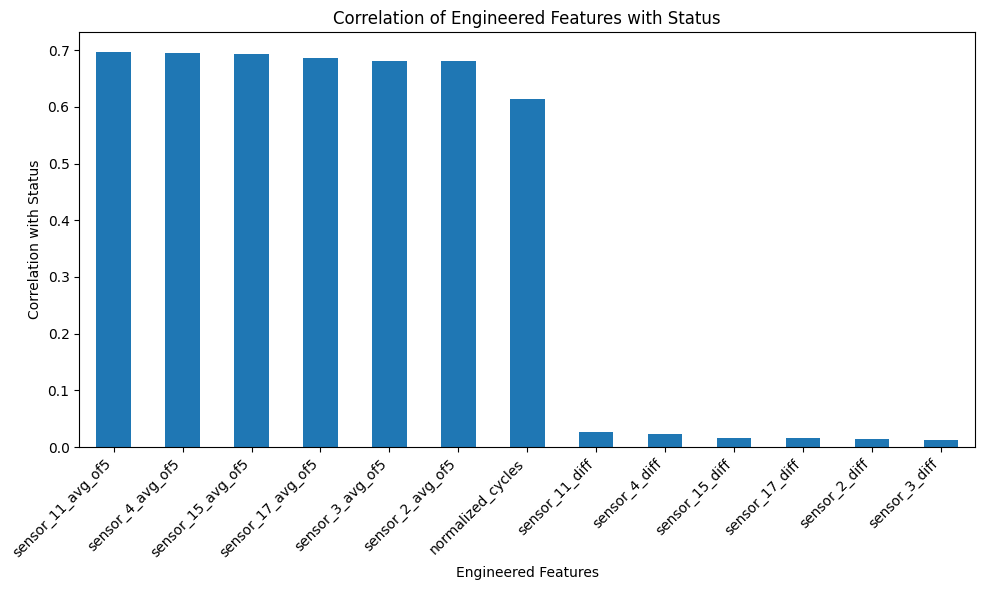

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_selection import mutual_info_classif
from sklearn.preprocessing import StandardScaler

#set y equal to status because thats what we want to predict
X = df.drop('Status', axis=1)
y = df['Status']

#calculate the mutual information scores
mi_scores = mutual_info_classif(X, y, random_state=1)
mi_scores_df = pd.DataFrame({'Feature': X.columns, 'Mutual_Information': mi_scores})
mi_scores_df = mi_scores_df.sort_values(by='Mutual_Information', ascending=False)

print("Top 15 Features by Mutual Information:\n", mi_scores_df.head(15))

#choosing the top 15 features to avoid overfitting
selected_features = mi_scores_df['Feature'].head(15).tolist()
X_selected = X[selected_features]

print("\nSelected Features:", selected_features)
print("Shape of Selected Feature Set:", X_selected.shape)

df_selected = pd.concat([X_selected, df['Status']], axis=1)
print("\nUpdated Dataset Shape with Selected Features:", df_selected.shape)

#correlations of engineered features with status
engineered_features = [col for col in df.columns if any(f'{sensor}_' in col for sensor in top_sensors) or col == 'normalized_cycles']
correlations = df[engineered_features + ['Status']].corr()['Status'].sort_values(ascending=False)
engineered_correlations = correlations.drop('Status')  # Exclude self-correlation

#plotting correlations of engineered features
plt.figure(figsize=(10, 6))
engineered_correlations.plot(kind='bar')
plt.title('Correlation of Engineered Features with Status')
plt.xlabel('Engineered Features')
plt.ylabel('Correlation with Status')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

Applying and Comparing Models

Logistic Regression Results:
Accuracy: 0.976
Precision: 0.919
Recall: 0.921
F1 Score: 0.920
AUC: 0.996

Logistic Regression 5-Fold Cross-Validation Recall Scores: [0.92580645 0.86774194 0.90645161 0.91774194 0.93064516]
Mean Recall: 0.910 (+/- 0.045)



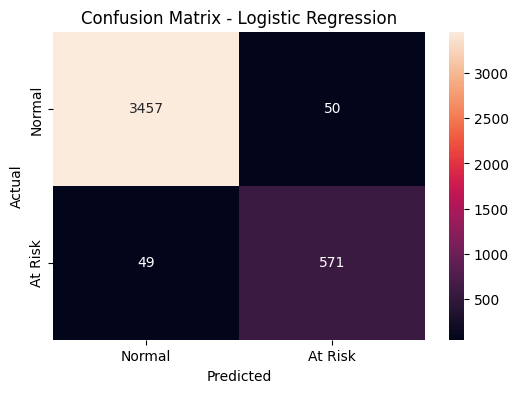

In [ ]:
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

#creating training and testing splits
X_train, X_test, y_train, y_test = train_test_split(X_selected, y, test_size=0.2, random_state=1, stratify=y)

#training logistic regression
log_reg = LogisticRegression(max_iter=1000, random_state=1)
log_reg.fit(X_train, y_train)
y_pred_log = log_reg.predict(X_test)

print("Logistic Regression Results:")
print(f"Accuracy: {accuracy_score(y_test, y_pred_log):.3f}")
print(f"Precision: {precision_score(y_test, y_pred_log):.3f}")
print(f"Recall: {recall_score(y_test, y_pred_log):.3f}")
print(f"F1 Score: {f1_score(y_test, y_pred_log):.3f}")
print(f"AUC: {roc_auc_score(y_test, log_reg.predict_proba(X_test)[:, 1]):.3f}")

#cross validation
cv_scores = cross_val_score(log_reg, X_selected, y, cv=5, scoring='recall')
print("\nLogistic Regression 5-Fold Cross-Validation Recall Scores:", cv_scores)
print(f"Mean Recall: {cv_scores.mean():.3f} (+/- {cv_scores.std() * 2:.3f})\n")

#confusion matrix
cm = confusion_matrix(y_test, y_pred_log)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', xticklabels=['Normal', 'At Risk'], yticklabels=['Normal', 'At Risk'])
plt.title('Confusion Matrix - Logistic Regression')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

XGBoost Results:
Accuracy: 0.976
Precision: 0.921
Recall: 0.923
F1 Score: 0.922
AUC: 0.996

Random Forest Results:
Accuracy: 0.977
Precision: 0.916
Recall: 0.932
F1 Score: 0.924
AUC: 0.996

Random Forest 5-Fold Cross-Validation Recall Scores: [0.92903226 0.85967742 0.91290323 0.92419355 0.93225806]
Mean Recall: 0.912 (+/- 0.054)


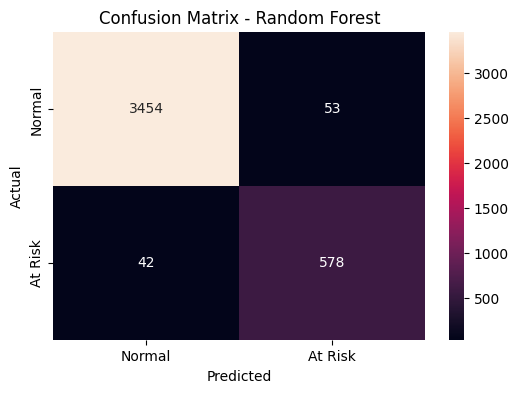

In [ ]:
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

X_train, X_test, y_train, y_test = train_test_split(X_selected, y, test_size=0.2, random_state=1, stratify=y)

#initialize and train XGBoost
xgb_clf = XGBClassifier(random_state=1, eval_metric='logloss')
xgb_clf.fit(X_train, y_train)
y_pred_xgb = xgb_clf.predict(X_test)

print("XGBoost Results:")
print(f"Accuracy: {accuracy_score(y_test, y_pred_xgb):.3f}")
print(f"Precision: {precision_score(y_test, y_pred_xgb):.3f}")
print(f"Recall: {recall_score(y_test, y_pred_xgb):.3f}")
print(f"F1 Score: {f1_score(y_test, y_pred_xgb):.3f}")
print(f"AUC: {roc_auc_score(y_test, xgb_clf.predict_proba(X_test)[:, 1]):.3f}\n")

#initialize and train random forest
rf_clf = RandomForestClassifier(random_state=1)
rf_clf.fit(X_train, y_train)
y_pred_rf = rf_clf.predict(X_test)

print("Random Forest Results:")
print(f"Accuracy: {accuracy_score(y_test, y_pred_rf):.3f}")
print(f"Precision: {precision_score(y_test, y_pred_rf):.3f}")
print(f"Recall: {recall_score(y_test, y_pred_rf):.3f}")
print(f"F1 Score: {f1_score(y_test, y_pred_rf):.3f}")
print(f"AUC: {roc_auc_score(y_test, rf_clf.predict_proba(X_test)[:, 1]):.3f}")

#cross validation
cv_scores_rf = cross_val_score(rf_clf, X_selected, y, cv=5, scoring='recall')
print("\nRandom Forest 5-Fold Cross-Validation Recall Scores:", cv_scores_rf)
print(f"Mean Recall: {cv_scores_rf.mean():.3f} (+/- {cv_scores_rf.std() * 2:.3f})")

#confusion matrix
cm = confusion_matrix(y_test, y_pred_rf)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', xticklabels=['Normal', 'At Risk'], yticklabels=['Normal', 'At Risk'])
plt.title('Confusion Matrix - Random Forest')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

MLP Results:
Accuracy: 0.973
Precision: 0.915
Recall: 0.902
F1 Score: 0.908
AUC: 0.995

MLP 5-Fold Cross-Validation Recall Scores: [0.94354839 0.86774194 0.88387097 0.86451613 0.88548387]
Mean Recall: 0.889 (+/- 0.057)


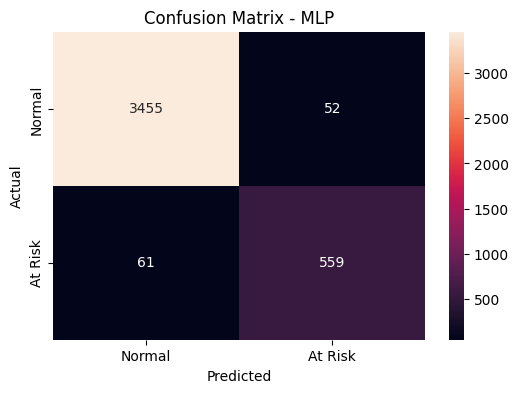

In [ ]:
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

X_train, X_test, y_train, y_test = train_test_split(X_selected, y, test_size=0.2, random_state=1, stratify=y)

#initialize and train MLP
mlp_clf = MLPClassifier(hidden_layer_sizes=(100, 50), max_iter=500, random_state=1)
mlp_clf.fit(X_train, y_train)
y_pred_mlp = mlp_clf.predict(X_test)

print("MLP Results:")
print(f"Accuracy: {accuracy_score(y_test, y_pred_mlp):.3f}")
print(f"Precision: {precision_score(y_test, y_pred_mlp):.3f}")
print(f"Recall: {recall_score(y_test, y_pred_mlp):.3f}")
print(f"F1 Score: {f1_score(y_test, y_pred_mlp):.3f}")
print(f"AUC: {roc_auc_score(y_test, mlp_clf.predict_proba(X_test)[:, 1]):.3f}")

#cross validation
cv_scores_mlp = cross_val_score(mlp_clf, X_selected, y, cv=5, scoring='recall')
print("\nMLP 5-Fold Cross-Validation Recall Scores:", cv_scores_mlp)
print(f"Mean Recall: {cv_scores_mlp.mean():.3f} (+/- {cv_scores_mlp.std() * 2:.3f})")

#confusion matrix
cm = confusion_matrix(y_test, y_pred_mlp)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', xticklabels=['Normal', 'At Risk'], yticklabels=['Normal', 'At Risk'])
plt.title('Confusion Matrix - MLP')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

In [ ]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

#parameter grid
param_grid = {
    'n_estimators': [100, 200],  #number of trees
    'max_depth': [10, 20, None],  #max depth of trees
    'min_samples_split': [2, 5],  #min samples to split
    'class_weight': ['balanced', None]
}

#our random forest
rf_clf = RandomForestClassifier(random_state=1)

#grid search with cross validation focused on optimizing recall
grid_search = GridSearchCV(rf_clf, param_grid, cv=5, scoring='recall', n_jobs=-1)
grid_search.fit(X_train, y_train)

best_rf = grid_search.best_estimator_
print("Best Parameters:", grid_search.best_params_)

#using the test set
y_pred_best_rf = best_rf.predict(X_test)
print("\nTuned Random Forest Results:")
print(f"Accuracy: {accuracy_score(y_test, y_pred_best_rf):.3f}")
print(f"Precision: {precision_score(y_test, y_pred_best_rf):.3f}")
print(f"Recall: {recall_score(y_test, y_pred_best_rf):.3f}")
print(f"F1 Score: {f1_score(y_test, y_pred_best_rf):.3f}")
print(f"AUC: {roc_auc_score(y_test, best_rf.predict_proba(X_test)[:, 1]):.3f}")

Best Parameters: {'class_weight': 'balanced', 'max_depth': 10, 'min_samples_split': 5, 'n_estimators': 100}

Tuned Random Forest Results:
Accuracy: 0.971
Precision: 0.865
Recall: 0.960
F1 Score: 0.910
AUC: 0.995


Final Tuned Random Forest Results:
Accuracy: 0.971
Precision: 0.863
Recall: 0.961
F1 Score: 0.909
AUC: 0.995


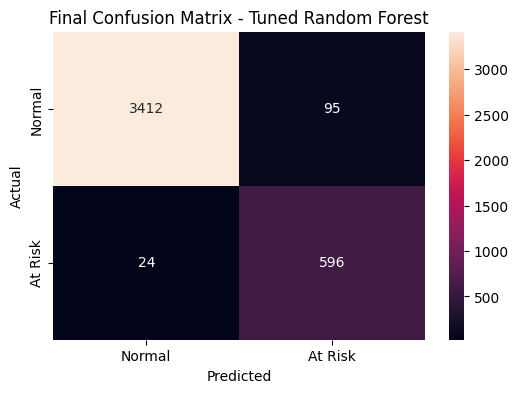

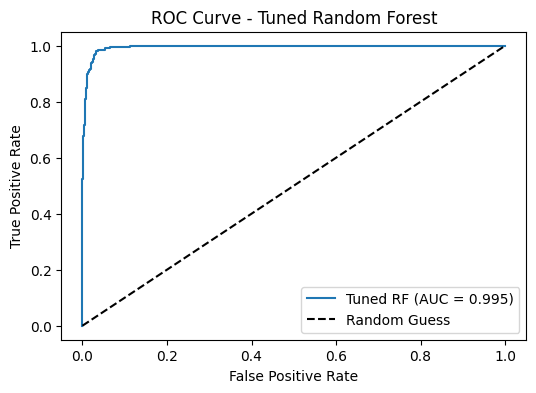


Final Tuned Random Forest 5-Fold Cross-Validation Recall Scores: [0.95       0.93548387 0.95483871 0.9483871  0.95      ]
Mean Recall: 0.948 (+/- 0.013)


In [ ]:
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, roc_curve
import matplotlib.pyplot as plt
import seaborn as sns

X_train, X_test, y_train, y_test = train_test_split(X_selected, y, test_size=0.2, random_state=1, stratify=y)

#best tuned model
best_rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    min_samples_split=5,
    class_weight='balanced',
    random_state=1
)
best_rf.fit(X_train, y_train)
y_pred = best_rf.predict(X_test)

print("Final Tuned Random Forest Results:")
print(f"Accuracy: {accuracy_score(y_test, y_pred):.3f}")
print(f"Precision: {precision_score(y_test, y_pred):.3f}")
print(f"Recall: {recall_score(y_test, y_pred):.3f}")
print(f"F1 Score: {f1_score(y_test, y_pred):.3f}")
print(f"AUC: {roc_auc_score(y_test, best_rf.predict_proba(X_test)[:, 1]):.3f}")

#confusion matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', xticklabels=['Normal', 'At Risk'], yticklabels=['Normal', 'At Risk'])
plt.title('Final Confusion Matrix - Tuned Random Forest')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

#ROC curve
fpr, tpr, _ = roc_curve(y_test, best_rf.predict_proba(X_test)[:, 1])
plt.figure(figsize=(6, 4))
plt.plot(fpr, tpr, label=f'Tuned RF (AUC = {roc_auc_score(y_test, best_rf.predict_proba(X_test)[:, 1]):.3f})')
plt.plot([0, 1], [0, 1], 'k--', label='Random Guess')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Tuned Random Forest')
plt.legend()
plt.show()

#cross validation
cv_scores = cross_val_score(best_rf, X_selected, y, cv=5, scoring='recall')
print("\nFinal Tuned Random Forest 5-Fold Cross-Validation Recall Scores:", cv_scores)
print(f"Mean Recall: {cv_scores.mean():.3f} (+/- {cv_scores.std() * 2:.3f})")

Conclusion Using Best Model

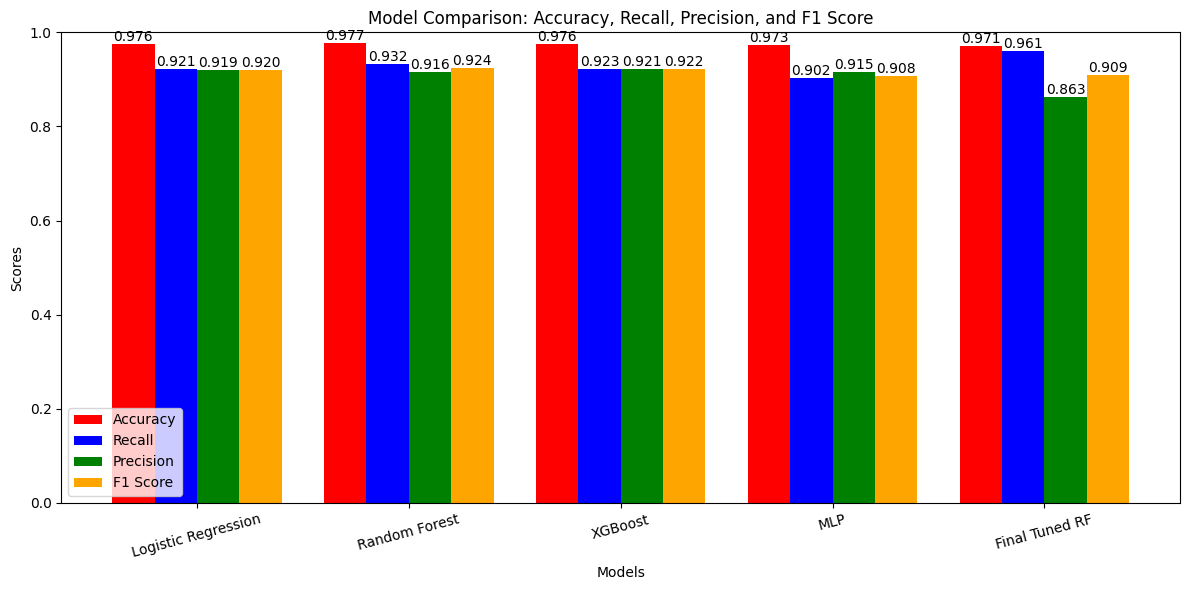

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

models = ['Logistic Regression', 'Random Forest', 'XGBoost', 'MLP', 'Final Tuned RF']
accuracy = [0.976, 0.977, 0.976, 0.973, 0.971]
recall = [0.921, 0.932, 0.923, 0.902, 0.961]
precision = [0.919, 0.916, 0.921, 0.915, 0.863]
f1 = [0.920, 0.924, 0.922, 0.908, 0.909]

x = np.arange(len(models))
width = 0.2

fig, ax = plt.subplots(figsize=(12, 6))
bars1 = ax.bar(x - 1.5 * width, accuracy, width, label='Accuracy', color='red')
bars2 = ax.bar(x - 0.5 * width, recall, width, label='Recall', color='blue')
bars3 = ax.bar(x + 0.5 * width, precision, width, label='Precision', color='green')
bars4 = ax.bar(x + 1.5 * width, f1, width, label='F1 Score', color='orange')

#labels and title
ax.set_xlabel('Models')
ax.set_ylabel('Scores')
ax.set_title('Model Comparison: Accuracy, Recall, Precision, and F1 Score')
ax.set_xticks(x)
ax.set_xticklabels(models, rotation=15)
ax.legend()
ax.set_ylim(0, 1)

#labels
for bars in [bars1, bars2, bars3, bars4]:
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width() / 2, height, f'{height:.3f}',
                ha='center', va='bottom')

plt.tight_layout()
plt.show()